ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

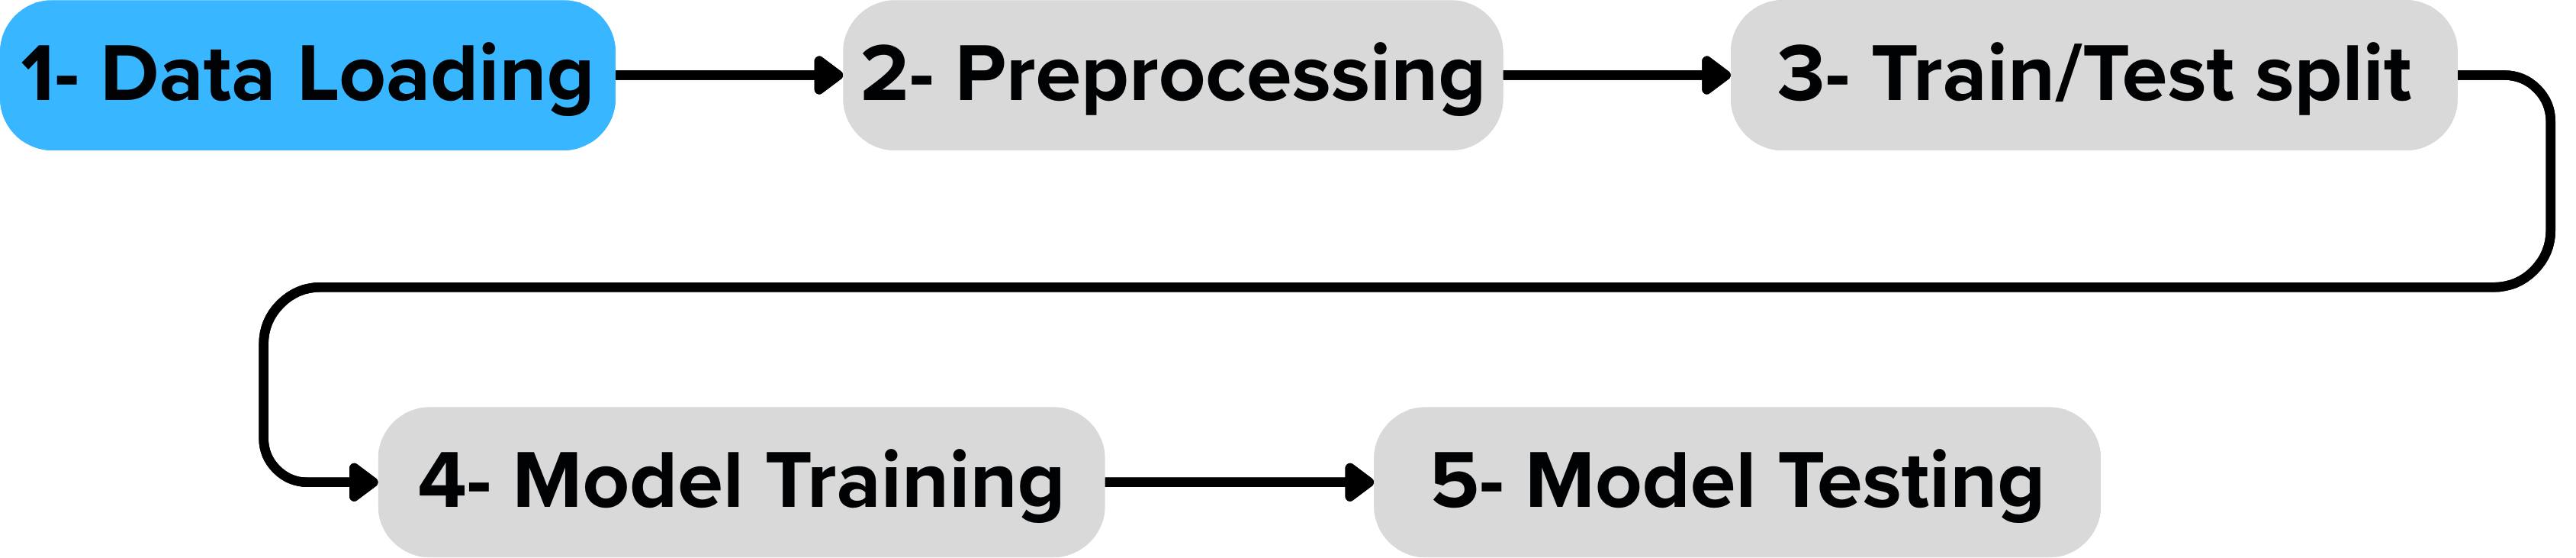

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['figure.figsize'] = (8, 5)


In [ ]:


from pathlib import Path


candidates = [Path("test.csv"), Path("/mnt/data/test.csv")]
DATA_PATH = None
for p in candidates:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Couldn't find test.csv. Put it in the same folder as this notebook or update the path.")

df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH.resolve())
df.head()

Loaded: /mnt/data/test.csv


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


### Check Missing Values

In [ ]:

df.isna().head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:

df.isna().sum().sort_values(ascending=False)

id               0
pc               0
touch_screen     0
three_g          0
talk_time        0
sc_w             0
sc_h             0
ram              0
px_width         0
px_height        0
n_cores          0
battery_power    0
mobile_wt        0
m_dep            0
int_memory       0
four_g           0
fc               0
dual_sim         0
clock_speed      0
blue             0
wifi             0
dtype: int64

### Check duplicate rows

In [ ]:

dup_mask = df.duplicated()
print("Number of duplicated rows:", dup_mask.sum())
df[dup_mask].head()

Number of duplicated rows: 0


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi


### No. of rows and columns

In [ ]:


print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1000, 21) 

number of rows:  1000
number of columns:  21


### Data type of columns

In [ ]:

df.dtypes

id                 int64
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
dtype: object

In [ ]:



df['id'] = df['id'].astype(int)


binary_cols = ['blue','dual_sim','four_g','three_g','touch_screen','wifi']
for c in binary_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

df.dtypes

id                  int64
battery_power       int64
blue             category
clock_speed       float64
dual_sim         category
fc                  int64
four_g           category
int_memory          int64
m_dep             float64
mobile_wt           int64
n_cores             int64
pc                  int64
px_height           int64
px_width            int64
ram                 int64
sc_h                int64
sc_w                int64
talk_time           int64
three_g          category
touch_screen     category
wifi             category
dtype: object

### Descriptive summary Statistics

In [ ]:

df.describe(include='all')

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1000.000000,1000.000000,1000.0,1000.000000,1000.0,1000.000000,1000.0,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.0,1000.0
unique,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0
top,NaN,NaN,1.0,NaN,1.0,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0
freq,NaN,NaN,516.0,NaN,517.0,NaN,513.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,756.0,500.0,507.0
mean,500.500000,1248.510000,NaN,1.540900,NaN,4.593000,NaN,33.652000,0.517500,139.51100,...,10.054000,627.121000,1239.774000,2138.998000,11.995000,5.316000,11.085000,NaN,NaN,NaN
std,288.819436,432.458227,NaN,0.829268,NaN,4.463325,NaN,18.128694,0.280861,34.85155,...,6.095099,432.929699,439.670981,1088.092278,4.320607,4.240062,5.497636,NaN,NaN,NaN
min,1.000000,500.000000,NaN,0.500000,NaN,0.000000,NaN,2.000000,0.100000,80.00000,...,0.000000,0.000000,501.000000,263.000000,5.000000,0.000000,2.000000,NaN,NaN,NaN
25%,250.750000,895.000000,NaN,0.700000,NaN,1.000000,NaN,18.000000,0.300000,109.75000,...,5.000000,263.750000,831.750000,1237.250000,8.000000,2.000000,6.750000,NaN,NaN,NaN
50%,500.500000,1246.500000,NaN,1.500000,NaN,3.000000,NaN,34.500000,0.500000,139.00000,...,10.000000,564.500000,1250.000000,2153.500000,12.000000,5.000000,11.000000,NaN,NaN,NaN
75%,750.250000,1629.250000,NaN,2.300000,NaN,7.000000,NaN,49.000000,0.800000,170.00000,...,16.000000,903.000000,1637.750000,3065.500000,16.000000,8.000000,16.000000,NaN,NaN,NaN


### Univariate Analysis

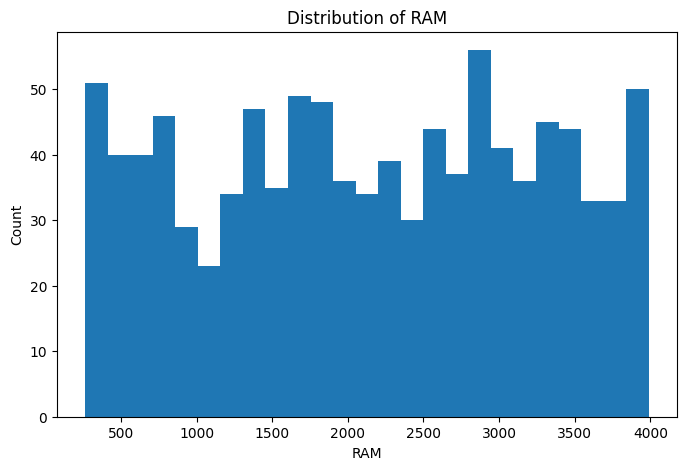

In [10]:
plt.figure()
plt.hist(df['ram'], bins=25)
plt.title("Distribution of RAM")
plt.xlabel("RAM")
plt.ylabel("Count")
plt.show()

- Shows how RAM values are distributed
- Skewness shows whether most phones have low, medium, or high RAM

### Distribution of RAM

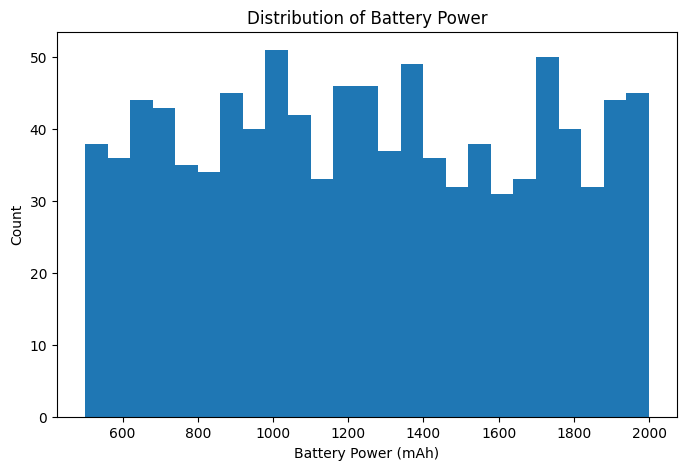

In [11]:
plt.figure()
plt.hist(df['battery_power'], bins=25)
plt.title("Distribution of Battery Power")
plt.xlabel("Battery Power (mAh)")
plt.ylabel("Count")
plt.show()

## Bivariate Analysis

### Average RAM by 4G

/tmp/ipykernel_803/267146913.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ram_by_4g = df.groupby('four_g')['ram'].mean().sort_index()
/opt/pyvenv/lib/python3.11/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)


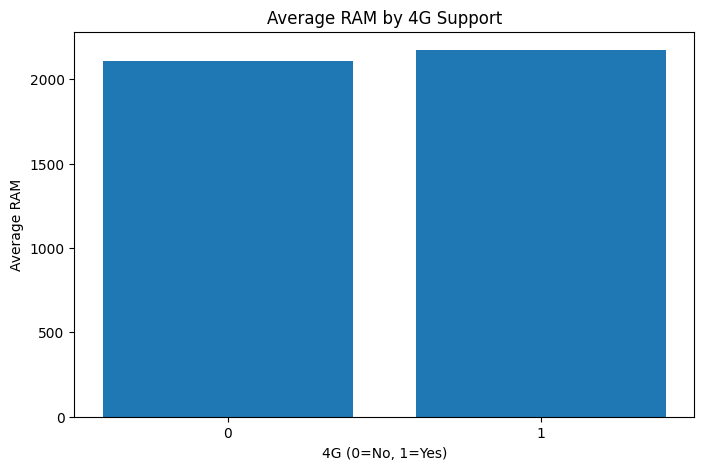

four_g
0    2106.339181
1    2173.400411
Name: ram, dtype: float64

In [ ]:

ram_by_4g = df.groupby('four_g')['ram'].mean().sort_index()

plt.figure()
plt.bar(ram_by_4g.index.astype(str), ram_by_4g.values)
plt.title("Average RAM by 4G Support")
plt.ylabel("Average RAM")
plt.xlabel("4G (0=No, 1=Yes)")
plt.show()

ram_by_4g

### Average Battery Power by Dual SIM

/tmp/ipykernel_803/478900117.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bp_by_dualsim = df.groupby('dual_sim')['battery_power'].mean().sort_index()
/opt/pyvenv/lib/python3.11/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)


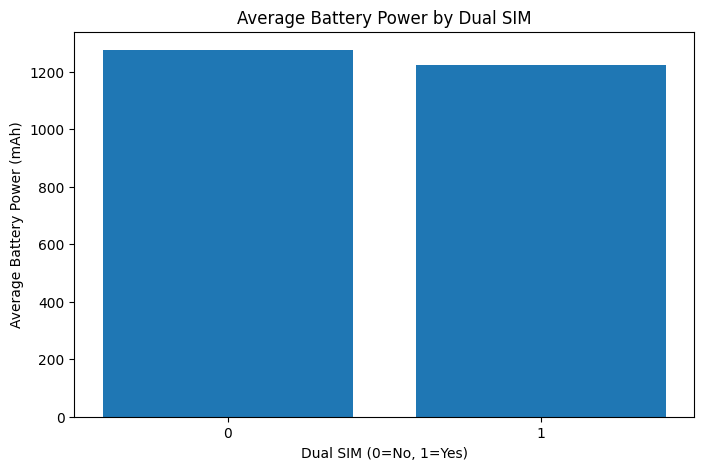

dual_sim
0    1275.865424
1    1222.953578
Name: battery_power, dtype: float64

In [ ]:

bp_by_dualsim = df.groupby('dual_sim')['battery_power'].mean().sort_index()

plt.figure()
plt.bar(bp_by_dualsim.index.astype(str), bp_by_dualsim.values)
plt.title("Average Battery Power by Dual SIM")
plt.ylabel("Average Battery Power (mAh)")
plt.xlabel("Dual SIM (0=No, 1=Yes)")
plt.show()

bp_by_dualsim

### Top 10 Phones by RAM

In [ ]:

top10_ram = df[['id','ram','battery_power','px_width','px_height']].sort_values('ram', ascending=False).head(10)
top10_ram

,id,ram,battery_power,px_width,px_height
507,508,3989,1767,556,461
597,598,3984,1038,1186,79
109,110,3976,769,1115,470
283,284,3975,1687,1461,924
156,157,3973,1933,1846,1286
336,337,3969,1877,610,134
657,658,3964,1260,1109,973
238,239,3959,1240,1319,477
989,990,3954,635,1597,1257
86,87,3953,942,797,336


### RAM vs Battery Power Relationship

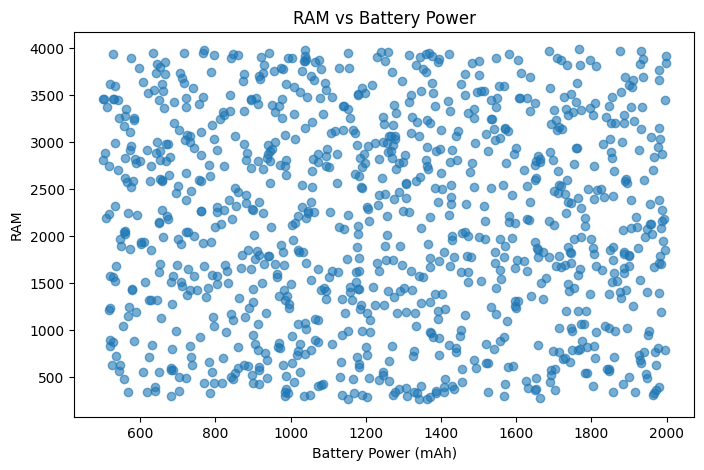

In [15]:
plt.figure()
plt.scatter(df['battery_power'], df['ram'], alpha=0.6)
plt.title("RAM vs Battery Power")
plt.xlabel("Battery Power (mAh)")
plt.ylabel("RAM")
plt.show()

### Correlation Matrix

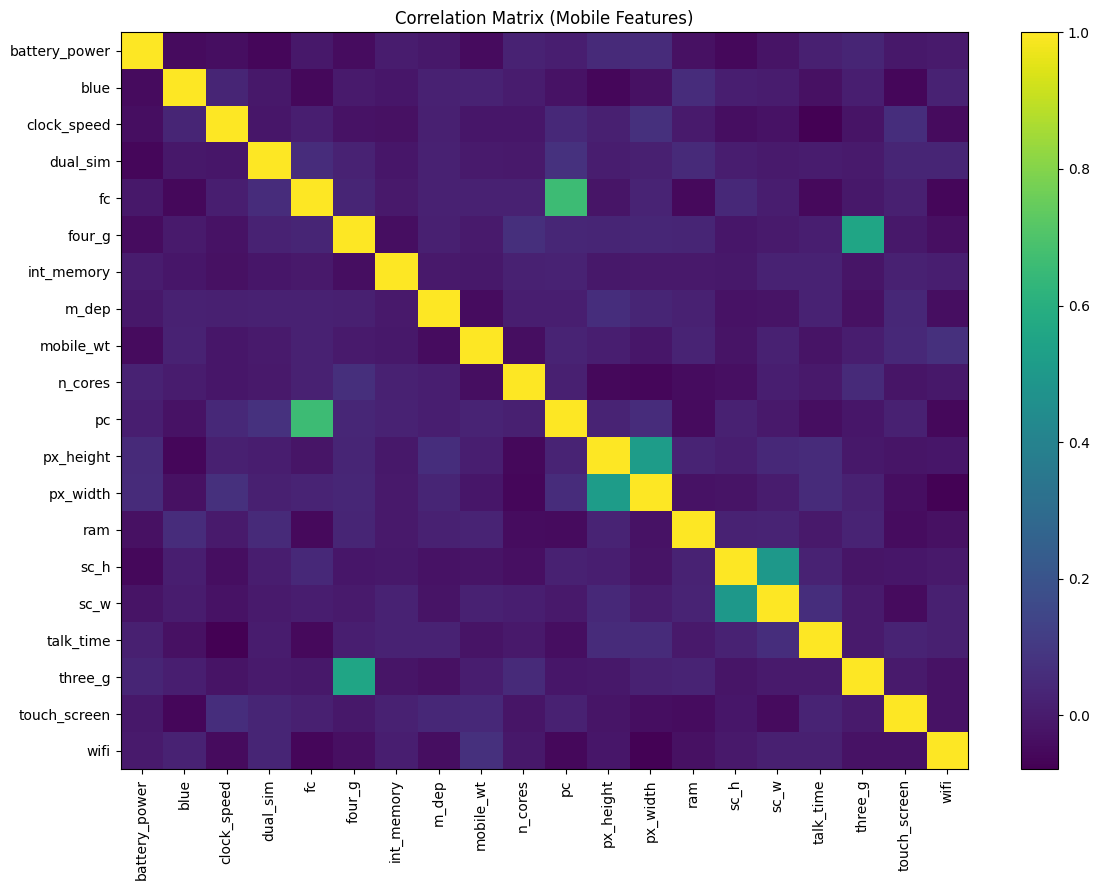

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
battery_power,1.000000,-0.046610,-0.039075,-0.061171,-0.007846,-0.042520,0.003751,-0.009065,-0.047065,0.025732,0.012847,0.048647,0.053365,-0.032366,-0.055665,-0.023905,0.015546,3.151417e-02,-1.013784e-02,-0.000414
blue,-0.046610,1.000000,0.034754,-0.011100,-0.056063,-0.001169,-0.012416,0.018319,0.023513,0.003283,-0.025247,-0.058810,-0.032054,0.057570,0.012780,0.004223,-0.031995,1.352986e-02,-6.003074e-02,0.025568
clock_speed,-0.039075,0.034754,1.000000,-0.012423,0.010127,-0.024665,-0.030487,0.016995,-0.014107,-0.012247,0.047469,0.017277,0.070585,-0.000650,-0.039503,-0.027138,-0.078797,-2.140644e-02,6.189276e-02,-0.048593
dual_sim,-0.061171,-0.011100,-0.012423,1.000000,0.057606,0.024907,-0.012158,0.021760,-0.001734,-0.003129,0.073936,0.006842,0.015610,0.048171,0.006295,-0.002064,0.004390,6.895838e-04,3.401967e-02,0.031545
fc,-0.007846,-0.056063,0.010127,0.057606,1.000000,0.032832,-0.006565,0.020859,0.018353,0.020828,0.659338,-0.017982,0.030550,-0.051997,0.045158,0.006115,-0.051458,-1.112104e-02,1.546706e-02,-0.060373
four_g,-0.042520,-0.001169,-0.024665,0.024907,0.032832,1.000000,-0.037488,0.014806,-0.000509,0.066716,0.037669,0.033655,0.036545,0.030821,-0.015087,-0.000893,0.013692,5.535283e-01,-1.000338e-02,-0.035652
int_memory,0.003751,-0.012416,-0.030487,-0.012158,-0.006565,-0.037488,1.000000,-0.004386,-0.010447,0.021601,0.022682,-0.009564,-0.003877,-0.007107,-0.009249,0.024521,0.023759,-1.592239e-02,2.218589e-02,0.011860
m_dep,-0.009065,0.018319,0.016995,0.021760,0.020859,0.014806,-0.004386,1.000000,-0.041994,0.010062,0.012663,0.062559,0.034861,0.018349,-0.026160,-0.023393,0.024124,-2.927827e-02,4.025363e-02,-0.039705
mobile_wt,-0.047065,0.023513,-0.014107,-0.001734,0.018353,-0.000509,-0.010447,-0.041994,1.000000,-0.038908,0.027343,0.011157,-0.014577,0.028786,-0.022053,0.022148,-0.021704,6.261881e-03,4.452531e-02,0.069762
n_cores,0.025732,0.003283,-0.012247,-0.003129,0.020828,0.066716,0.021601,0.010062,-0.038908,1.000000,0.014376,-0.054433,-0.059388,-0.042750,-0.034057,0.012830,-0.005640,5.093589e-02,-1.661558e-02,-0.007256


In [ ]:

num_df = df.copy()


for c in num_df.columns:
    if str(num_df[c].dtype) == 'category':
        num_df[c] = num_df[c].astype(int)

corr = num_df.drop(columns=['id']).corr(numeric_only=True)

plt.figure(figsize=(12,9))
im = plt.imshow(corr.values, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix (Mobile Features)")
plt.tight_layout()
plt.show()

corr

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Average RAM by ID (trend)

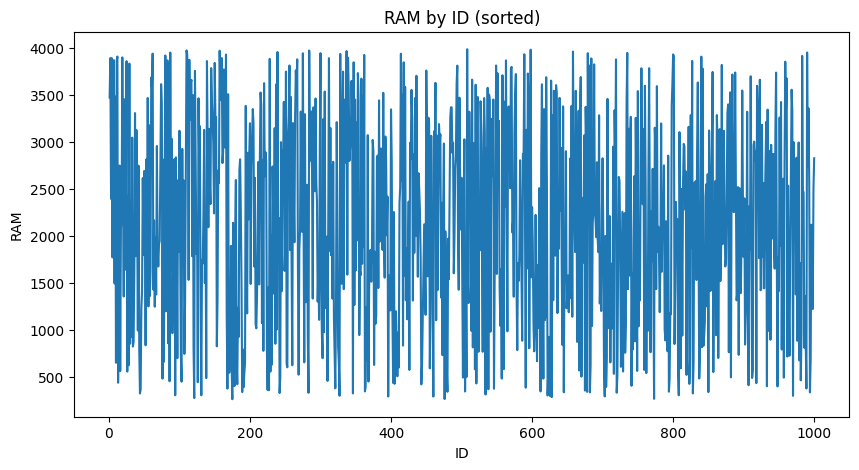

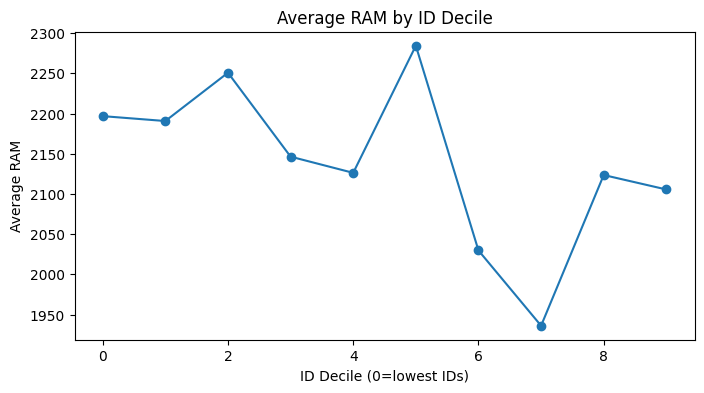

id_decile
0    2196.76
1    2190.67
2    2250.76
3    2146.37
4    2126.23
5    2284.33
6    2029.69
7    1936.11
8    2123.51
9    2105.55
Name: ram, dtype: float64

In [ ]:

df_sorted = df.sort_values('id')

plt.figure(figsize=(10,5))
plt.plot(df_sorted['id'], df_sorted['ram'])
plt.title("RAM by ID (sorted)")
plt.xlabel("ID")
plt.ylabel("RAM")
plt.show()


df_sorted['id_decile'] = pd.qcut(df_sorted['id'], 10, labels=False)
avg_ram_by_decile = df_sorted.groupby('id_decile')['ram'].mean()

plt.figure(figsize=(8,4))
plt.plot(avg_ram_by_decile.index, avg_ram_by_decile.values, marker='o')
plt.title("Average RAM by ID Decile")
plt.xlabel("ID Decile (0=lowest IDs)")
plt.ylabel("Average RAM")
plt.show()

avg_ram_by_decile

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.